In [21]:
import numpy as np
import sympy as sp
from IPython.display import display, Markdown, Latex

# =========================================================
# 16×16 Cross-MMI：计算第 1 个输出端口响应 E_out(1)
# 输入：a1 ... a16
# 单个 8×8 MMI 相位关系来自图2（Eq. 2-24），取均匀分光（1/sqrt(8)）
# =========================================================

N_sub = 8
N_total = 16
phi0 = 0.0  # 相位常数（弧度），若论文给定可在此修改

# ---------------------------------------------------------
# 1) 构造单个 8×8 MMI 传输矩阵（数值版）
#    论文中 i 为输入编号（自下而上），j 为输出编号（自上而下）。
#    我们用矩阵列对应输入端口（自上而下），所以需要对列做翻转（fliplr）。
# ---------------------------------------------------------
DEN = 4 * N_sub  # N=8 -> 32，所有相位都是 π/DEN 的整数倍
m = np.zeros((N_sub, N_sub), dtype=int)
for j in range(1, N_sub + 1):        # 输出：自上而下
    for i in range(1, N_sub + 1):    # 输入：论文中自下而上
        if (i + j) % 2 == 0:
            m[j - 1, i - 1] = DEN + (j - i) * (2 * N_sub - j + i)
        else:
            m[j - 1, i - 1] = (j + i - 1) * (2 * N_sub - j - i + 1)

Phi = (np.pi / DEN) * m + phi0
Phi = np.fliplr(Phi)  # 把输入端口编号转换成自上而下
T8_num = (1 / np.sqrt(N_sub)) * np.exp(1j * Phi)

# ---------------------------------------------------------
# 2) 组装 16×16 网络：左右各两个 8×8 MMI，中间为“4 路交叉”置换矩阵 W
#    端口约定：
#      输入 a1..a8  -> 左上 8×8 MMI（自上而下）
#      输入 a9..a16 -> 左下 8×8 MMI（自上而下）
#      输出 1..8    -> 右上 8×8 MMI（自上而下）
#      输出 9..16   -> 右下 8×8 MMI（自上而下）
# ---------------------------------------------------------
Z8 = np.zeros((8, 8), dtype=complex)
S = np.block([[T8_num, Z8], [Z8, T8_num]])

# 中间连线：外侧 4 路直通，中间 4 路上下互换（与示意图一致）
W = np.zeros((16, 16), dtype=complex)
W[0:4, 0:4]     = np.eye(4)
W[4:8, 8:12]    = np.eye(4)
W[8:12, 4:8]    = np.eye(4)
W[12:16, 12:16] = np.eye(4)

T16_num = S @ W @ S

# ---------------------------------------------------------
# 3) 把数值系数“量化”为干净的解析形式：
#    - 幅度平方 |c|^2 量化为分母为 2^k 的有理数（避免 nsimplify 猜出怪分母）
#    - 相位 angle(c)/π 量化为分母 32 的有理数（因为单级 MMI 相位就是 π/32 的整数倍）
# ---------------------------------------------------------
a = sp.Matrix(sp.symbols('a1:17'))

def quantize_coeff(val, *, mag2_den=256, phase_den=32, tol=1e-10):
    if abs(val) < tol:
        return sp.Integer(0)

    mag2_num = int(np.round((abs(val) ** 2) * mag2_den))
    if mag2_num == 0:
        return sp.Integer(0)
    mag2 = sp.Rational(mag2_num, mag2_den)
    mag = sp.sqrt(mag2)

    ph_num = int(np.round((np.angle(val) / np.pi) * phase_den))
    ph = sp.Rational(ph_num, phase_den)

    if ph == 0:
        return mag
    # 不在这里 simplify：避免 exp(I*pi*r) 被自动改写成 (-1)**r
    return mag * sp.exp(sp.I * sp.pi * ph)

def pow_minus_one_to_exp(expr):
    return sp.sympify(expr).replace(
        lambda x: isinstance(x, sp.Pow) and x.base == -1 and x.exp.is_Rational,
        lambda x: sp.exp(sp.I * sp.pi * x.exp),
    )

E_out_1 = sp.sympify(0)
for k in range(N_total):
    c = quantize_coeff(T16_num[0, k])
    if c != 0:
        E_out_1 += c * a[k]

E_out_1 = sp.simplify(E_out_1)
E_out_1_exp = sp.expand(pow_minus_one_to_exp(E_out_1))

# ---------------------------------------------------------
# 4) 严格按 a1..a16 数值升序展示
#    说明：Sympy 的默认 pretty/LaTeX 打印会按字典序重排（a10 会跑到 a2 前），
#          所以这里用“手工拼接 LaTeX”的方式保证输出顺序。
# ---------------------------------------------------------
latex_terms = []
for k in range(N_total):
    ck = pow_minus_one_to_exp(E_out_1_exp.coeff(a[k]))
    if ck != 0:
        latex_terms.append(f"{sp.latex(a[k])}\\left({sp.latex(ck, order='none')}\\right)")

E_out_1_ordered_latex = " + ".join(latex_terms) if latex_terms else "0"

display(Markdown("### 16×16 结构第 1 个输出端口响应 $E_{out}(1)$（输入 $a_1\\ldots a_{16}$）"))
display(Latex(r"$E_{out}(1) = " + E_out_1_ordered_latex + r"$"))

### 16×16 结构第 1 个输出端口响应 $E_{out}(1)$（输入 $a_1\ldots a_{16}$）

<IPython.core.display.Latex object>

In [22]:
# =========================================================
# 新增第二部分：加入16个热电极来调控中间波导的相位
# 计算加入了相移器后的新传输矩阵，并计算第一个输出端口的响应
# =========================================================

# 1) 定义 16 个相位变量 θ1 ... θ16
theta = sp.symbols('theta_1:17', real=True)
D = sp.diag(*[sp.exp(sp.I * t) for t in theta])

# 2) 为了进行精确的解析计算，首先利用已有的 quantize_coeff 函数
#    将原本含有浮点数的数值矩阵 S 和 W 转化为符号矩阵（化简为精准的分数与指数）。
S_sym = sp.Matrix(N_total, N_total, lambda i, j: quantize_coeff(S[i, j]))
W_sym = sp.Matrix(N_total, N_total, lambda i, j: quantize_coeff(W[i, j]))

# 3) 计算新的传输矩阵
#    将相位调制对角矩阵 D 加在第一级 S 输出 和 W 交叉之间
#    （或者 W 之后，物理上对应调整具体的某号波导）。这里取 S -> D -> W -> S
T16_sym_new = S_sym * W_sym * D * S_sym

# 4) 计算第一个输出端口（索引0）的表达式 E_out_new(1)
E_out_1_new = sp.sympify(0)
for k in range(N_total):
    c_new = T16_sym_new[0, k]
    if c_new != 0:
        E_out_1_new += c_new * a[k]

# 将所有以 (-1)**r 形式出现的分数次幂转回指数形式
E_out_1_new = sp.expand(pow_minus_one_to_exp(E_out_1_new))

# 5) 严格按 a1..a16 升序展示
latex_terms_new = []
for k in range(N_total):
    coeff_k = E_out_1_new.coeff(a[k])
    if coeff_k != 0:
        # 对系数单独做指数转换保护
        coeff_k = pow_minus_one_to_exp(coeff_k)
        latex_terms_new.append(f"{sp.latex(a[k])}\\left({sp.latex(coeff_k, order='none')}\\right)")

E_out_1_ordered_latex_new = " + ".join(latex_terms_new) if latex_terms_new else "0"

display(Markdown("### 加入中间16个热电极相位调制后的结构：第 1 个输出端口响应 $E_{out}(1)$"))
display(Latex(r"$E_{out}(1) = " + E_out_1_ordered_latex_new + r"$"))


### 加入中间16个热电极相位调制后的结构：第 1 个输出端口响应 $E_{out}(1)$

<IPython.core.display.Latex object>

开始通过 Adam 优化器训练各层数网络...
n=4 layers: Final Loss = 12.171289
n=8 layers: Final Loss = 4.629516
n=12 layers: Final Loss = 0.926448
n=16 layers: Final Loss = 0.082473
n=20 layers: Final Loss = 0.000031


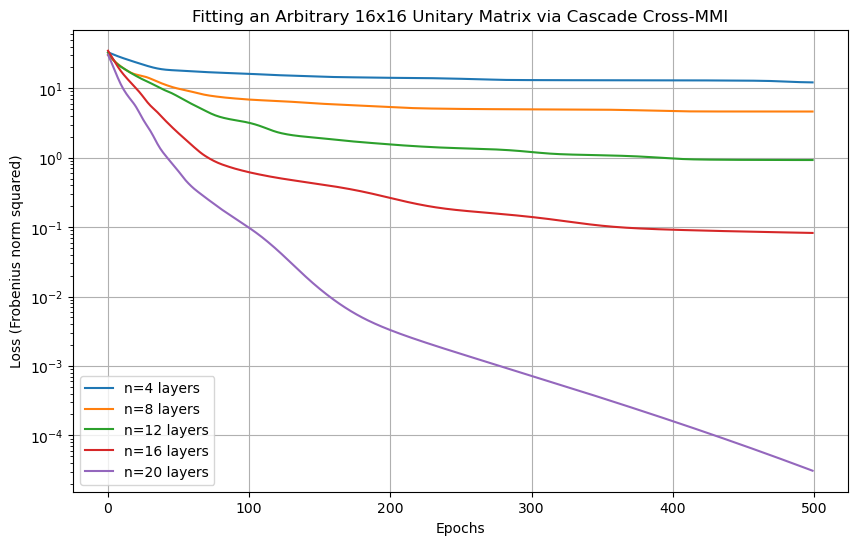

In [24]:
# =========================================================
# 探索不同级联层数 n 下梯度下降拟合任意幺正矩阵的效果
# =========================================================
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 将原 numpy 矩阵转为 PyTorch 张量
S_t = torch.tensor(S, dtype=torch.complex128)
W_t = torch.tensor(W, dtype=torch.complex128)

class CascadeMMINet(nn.Module):
    def __init__(self, n_layers):
        super().__init__()
        self.n_layers = n_layers
        # 初始化各层热电极的相位 theta
        self.theta = nn.Parameter(torch.rand(n_layers, 16, dtype=torch.float64) * 2 * torch.pi)
        
    def forward(self):
        # 初始输入穿过第一个 S
        T = S_t
        for i in range(self.n_layers):
            # 构造第 i 层的相位调制对角矩阵 D
            D = torch.diag(torch.exp(1j * self.theta[i]))
            # 级联新的一级 (W * D * S) => 虽然也可以表达为左乘
            # 这里的推导表示物理经过 D 后进入 W，再进入 S
            T = S_t @ W_t @ D @ T
        return T

# 生成一个随机的 16x16 目标幺正矩阵
torch.manual_seed(42)
rand_mat = torch.randn(16, 16, dtype=torch.complex128)
target_U, _ = torch.linalg.qr(rand_mat)  # 通过 QR 分解拿到一个真正随机的幺正矩阵

# 探索不同的层数 n
layers_to_test = [4, 8,12, 16, 20]
loss_history = {}

print("开始通过 Adam 优化器训练各层数网络...")
for n in layers_to_test:
    model = CascadeMMINet(n)
    # 使用 Adam 优化器，调整相位使其更逼近目标矩阵
    optimizer = torch.optim.Adam(model.parameters(), lr=0.035)
    losses = []
    
    for epoch in range(500):
        optimizer.zero_grad()
        out_U = model()
        # 损失函数使用 Frobenius 范数的平方，衡量两个矩阵元素差异
        loss = torch.sum(torch.abs(out_U - target_U)**2)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        
    loss_history[n] = losses
    print(f"n={n} layers: Final Loss = {losses[-1]:.6f}")

# 绘制损失曲线
plt.figure(figsize=(10, 6))
for n in layers_to_test:
    plt.plot(loss_history[n], label=f'n={n} layers')
plt.xlabel('Epochs')
plt.ylabel('Loss (Frobenius norm squared)')
plt.yscale('log')
plt.title('Fitting an Arbitrary 16x16 Unitary Matrix via Cascade Cross-MMI')
plt.legend()
plt.grid(True)
plt.show()

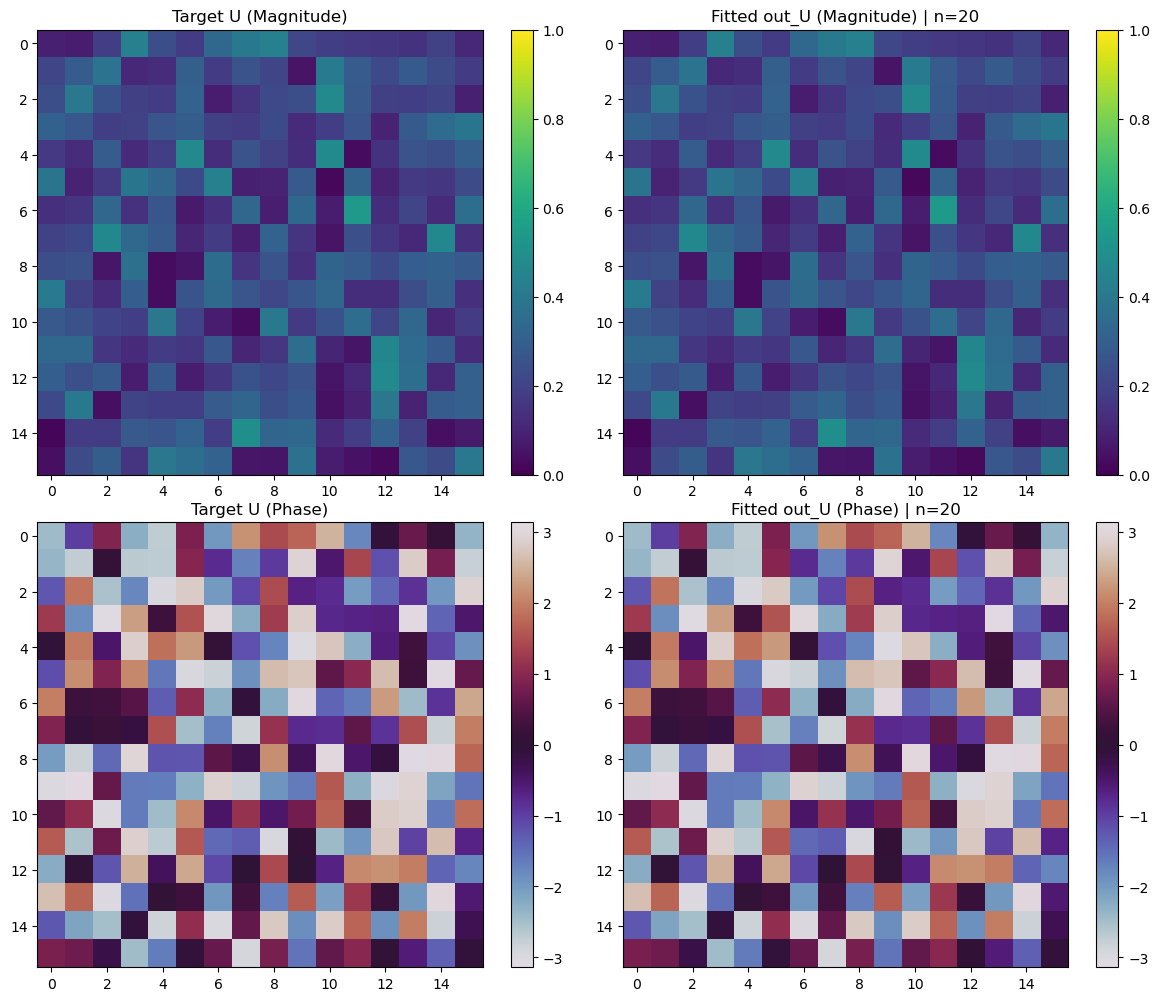

平均元素绝对误差 (Mean Absolute Error): 3.048325e-04


In [17]:
# =========================================================
# 可视化对比拟合结果 out_U 与目标矩阵 target_U
# =========================================================
import torch
# 获取最后一次训练 (n=20) 得到的输出矩阵
with torch.no_grad():
    out_U = model()

# 转换为 numpy 数组方便绘图
out_np = out_U.numpy()
target_np = target_U.numpy()

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# 绘制幅度对比
im0 = axs[0,0].imshow(np.abs(target_np), cmap='viridis', vmin=0, vmax=1)
axs[0,0].set_title("Target U (Magnitude)")
plt.colorbar(im0, ax=axs[0,0])

im1 = axs[0,1].imshow(np.abs(out_np), cmap='viridis', vmin=0, vmax=1)
axs[0,1].set_title(f"Fitted out_U (Magnitude) | n={model.n_layers}")
plt.colorbar(im1, ax=axs[0,1])

# 绘制相位对比
im2 = axs[1,0].imshow(np.angle(target_np), cmap='twilight', vmin=-np.pi, vmax=np.pi)
axs[1,0].set_title("Target U (Phase)")
plt.colorbar(im2, ax=axs[1,0])

im3 = axs[1,1].imshow(np.angle(out_np), cmap='twilight', vmin=-np.pi, vmax=np.pi)
axs[1,1].set_title(f"Fitted out_U (Phase) | n={model.n_layers}")
plt.colorbar(im3, ax=axs[1,1])

plt.tight_layout()
plt.show()

# 如果也想查看数值差异，可以打印平均误差
diff = np.mean(np.abs(out_np - target_np))
print(f"平均元素绝对误差 (Mean Absolute Error): {diff:.6e}")

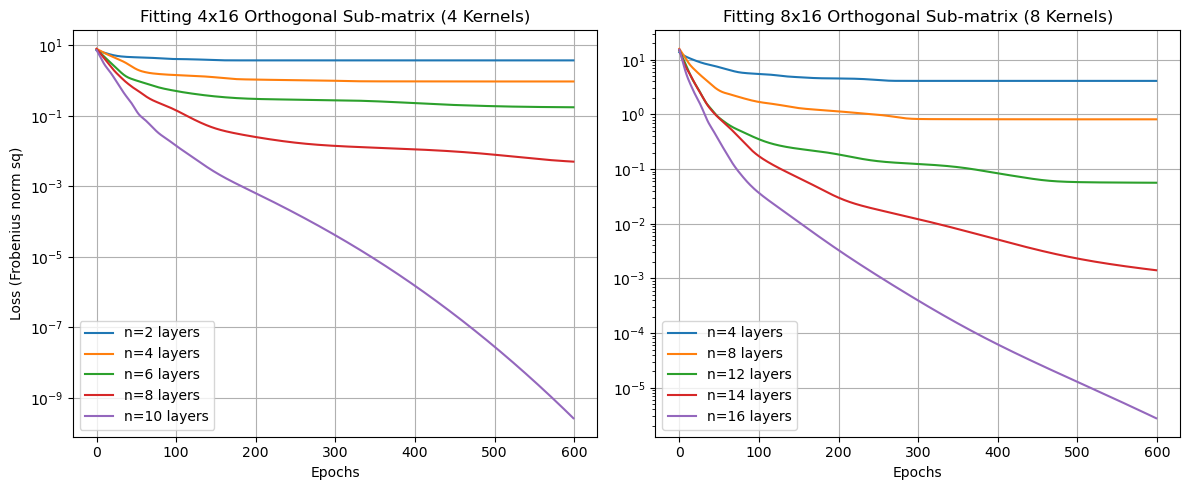

In [18]:
# =========================================================
# 探索仅拟合前 k 行（4个或8个卷积核）的梯度下降训练
# =========================================================
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 提取 k 行的目标矩阵（复数矩阵）
def train_submatrix(k_rows, n_layers, epochs=600):
    torch.manual_seed(42 + n_layers)
    
    # 【核心修正】：CascadeMMINet 是一个纯相位的无损级联网络，
    # 物理上它的每一次 forward 输出必然是一个严丝合缝的 16x16 酉矩阵。
    # 酉矩阵的任意一行的模长平方和必定绝对等于 1，并且各行彼此正交。
    # 如果目标目标奇异值小于 1（即有能量损耗），这个网络由于没有 VOA 衰减器，是死活无法降到 0 误差的！
    # 所以为了测试网络路由拟合的能力，我们直接截取一个标准的正交酉矩阵的前 k 行作为目标。
    rand_mat = torch.randn(16, 16, dtype=torch.complex128)
    U_full, _ = torch.linalg.qr(rand_mat)
    target_sub = U_full[:k_rows, :]
    
    model = CascadeMMINet(n_layers)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.03)
    losses = []
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        out_U = model()
        # 核心：Loss 只计算前 k 行的误差！忽略其余 16-k 行的内容
        out_sub = out_U[:k_rows, :]
        loss = torch.sum(torch.abs(out_sub - target_sub)**2)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        
    return losses

plt.figure(figsize=(12, 5))

# 1) 测试 k=4 (前4行)
plt.subplot(1, 2, 1)
for n in [2, 4, 6, 8, 10]:
    losses = train_submatrix(k_rows=4, n_layers=n)
    plt.plot(losses, label=f'n={n} layers')
plt.yscale('log')
plt.title('Fitting 4x16 Orthogonal Sub-matrix (4 Kernels)')
plt.xlabel('Epochs')
plt.ylabel('Loss (Frobenius norm sq)')
plt.legend()
plt.grid(True)

# 2) 测试 k=8 (前8行)
plt.subplot(1, 2, 2)
for n in [4, 8, 12,14, 16]:
    losses = train_submatrix(k_rows=8, n_layers=n)
    plt.plot(losses, label=f'n={n} layers')
plt.yscale('log')
plt.title('Fitting 8x16 Orthogonal Sub-matrix (8 Kernels)')
plt.xlabel('Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

开始测试端到端向量推理误差：

--- 拟合 4 个卷积核 (k=4) ---
   2 层网络 | 实际输出误差 (MSE): 2.900595e-01
   4 层网络 | 实际输出误差 (MSE): 9.058672e-02
   6 层网络 | 实际输出误差 (MSE): 3.594510e-03
   8 层网络 | 实际输出误差 (MSE): 3.092290e-05
  10 层网络 | 实际输出误差 (MSE): 2.044086e-09

--- 拟合 8 个卷积核 (k=8) ---
   4 层网络 | 实际输出误差 (MSE): 1.616941e-01
   8 层网络 | 实际输出误差 (MSE): 5.247065e-02
  12 层网络 | 实际输出误差 (MSE): 4.095285e-03
  14 层网络 | 实际输出误差 (MSE): 1.790393e-04
  16 层网络 | 实际输出误差 (MSE): 1.560902e-07

--- 拟合 16 个卷积核 (k=16) ---
   8 层网络 | 实际输出误差 (MSE): 2.680782e-01
  12 层网络 | 实际输出误差 (MSE): 5.944121e-02
  16 层网络 | 实际输出误差 (MSE): 5.015007e-03
  20 层网络 | 实际输出误差 (MSE): 4.086784e-09
  24 层网络 | 实际输出误差 (MSE): 2.371718e-11


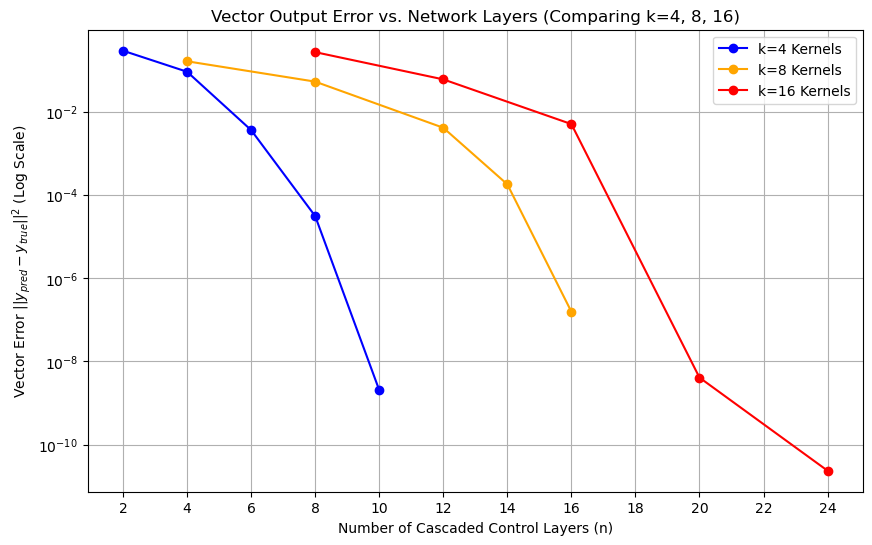

In [25]:
# =========================================================
# 评估端到端向量推理：输入一个随机向量，计算实际输出与理想输出的误差
# 对比 k=4, k=8, k=16（满阵）在不同层数下的表现
# =========================================================
import torch
import matplotlib.pyplot as plt

def evaluate_vector_inference(k_rows, n_layers, epochs=600):
    # 1. 重新快速训练提取出模型和目标矩阵
    # 给不同的配置增加一点不同的 seed 偏移，避免目标矩阵相关性
    torch.manual_seed(42 + n_layers + k_rows * 100)
    rand_mat = torch.randn(16, 16, dtype=torch.complex128)
    U_full, _ = torch.linalg.qr(rand_mat)
    target_sub = U_full[:k_rows, :]
    
    model = CascadeMMINet(n_layers)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.035)
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        out_U = model()
        out_sub = out_U[:k_rows, :]
        loss = torch.sum(torch.abs(out_sub - target_sub)**2)
        loss.backward()
        optimizer.step()
        
    # 2. 向量推理测试
    # 生成一个位于复数域的 16x1 随机输入信号
    x = torch.randn(16, 1, dtype=torch.complex128)
    # 能量归一化（物理输入光的总能量限制）
    x = x / torch.norm(x)
    
    with torch.no_grad():
        out_U_final = model()
        fitted_sub = out_U_final[:k_rows, :]
        
        # 理论标准输出 (Target) vs 物理网络的实际输出 (Predicted)
        y_true = target_sub @ x
        y_pred = fitted_sub @ x
        
        # 计算输出向量的 MSE 误差 (即 ||y_pred - y_true||^2)
        vector_loss = torch.sum(torch.abs(y_pred - y_true)**2).item()
        
    return vector_loss

# 定义要测试的不同核数量对应的层数配置
configurations = {
    4: [2, 4, 6, 8, 10],            # 4 个核 (1/4 矩阵)
    8: [4, 8, 12, 14, 16],          # 8 个核 (半阵)
    16: [8, 12, 16, 20, 24]         # 16 个核 (满阵/完整酉矩阵)
}

plt.figure(figsize=(10, 6))
colors = {4: 'blue', 8: 'orange', 16: 'red'}

print("开始测试端到端向量推理误差：")
for k_rows, layers in configurations.items():
    print(f"\n--- 拟合 {k_rows} 个卷积核 (k={k_rows}) ---")
    v_losses = []
    for n in layers:
        # 满阵因为变量多、非凸性强，在此给予稍微多一些 epoch 保证收敛
        epochs = 800 if k_rows == 16 else 600
        v_loss = evaluate_vector_inference(k_rows=k_rows, n_layers=n, epochs=epochs)
        v_losses.append(v_loss)
        print(f"  {n:2d} 层网络 | 实际输出误差 (MSE): {v_loss:.6e}")
    
    plt.plot(layers, v_losses, marker='o', linestyle='-', color=colors[k_rows], label=f'k={k_rows} Kernels')

# 可视化配置
plt.yscale('log')
plt.title('Vector Output Error vs. Network Layers (Comparing k=4, 8, 16)')
plt.xlabel('Number of Cascaded Control Layers (n)')
plt.ylabel('Vector Error $||y_{pred} - y_{true}||^2$ (Log Scale)')
plt.xticks(range(2, 25, 2))
plt.legend()
plt.grid(True)
plt.show()

In [31]:
# =========================================================
# 直观展示 y_pred 和 y_true 的具体数值与量级
# =========================================================
import torch

def show_sample_vectors(k_rows=8, n_layers=14, epochs=600):
    print(f"--- 观察具体量级：拟合 {k_rows} 个核，使用 {n_layers} 层网络 ---")
    torch.manual_seed(100) # 固定一个种子方便观看
    
    # 1. 准备物理网络和目标矩阵
    rand_mat = torch.randn(16, 16, dtype=torch.complex128)
    U_full, _ = torch.linalg.qr(rand_mat)
    target_sub = U_full[:k_rows, :]
    
    model = CascadeMMINet(n_layers)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.035)
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        out_U = model()
        loss = torch.sum(torch.abs(out_U[:k_rows, :] - target_sub)**2)
        loss.backward()
        optimizer.step()
        
    # 2. 向量测试
    x = torch.randn(16, 1, dtype=torch.complex128)
    x = x / torch.norm(x)  # 能量归一化 (总能量限制为1)
    
    with torch.no_grad():
        fitted_sub = model()[:k_rows, :]
        y_true = target_sub @ x
        y_pred = fitted_sub @ x
        
    # 3. 打印对比
    print(f"归一化输入端 x 的总能量 (||x||^2): {torch.sum(torch.abs(x)**2).item():.4f}")
    print(f"理想情况下输出的最大理论模长不可能超过 1.0 (因为目标是正交阵且输入模长为1)\n")
    
    print("逐元素对比 (展示前8个复数端口输出，形式为 实部 + 虚部 j):")
    
    for i in range(min(8, k_rows)):
        val_t = y_true[i, 0].item()
        val_p = y_pred[i, 0].item()
        diff = val_p - val_t
        print(f"端口 [{i}]")
        print(f"  理想目标 y_true : {val_t.real:+8.4f} {val_t.imag:+8.4f}j  --> (模长 = {abs(val_t):.4f})")
        print(f"  实际物理 y_pred : {val_p.real:+8.4f} {val_p.imag:+8.4f}j  --> (模长 = {abs(val_p):.4f})")
        print(f"  预测误差 Δy      : {diff.real:+8.4f} {diff.imag:+8.4f}j\n")

show_sample_vectors(k_rows=8, n_layers=14)

--- 观察具体量级：拟合 8 个核，使用 14 层网络 ---
归一化输入端 x 的总能量 (||x||^2): 1.0000
理想情况下输出的最大理论模长不可能超过 1.0 (因为目标是正交阵且输入模长为1)

逐元素对比 (展示前8个复数端口输出，形式为 实部 + 虚部 j):
端口 [0]
  理想目标 y_true :  -0.1461  +0.0530j  --> (模长 = 0.1554)
  实际物理 y_pred :  -0.1379  +0.0512j  --> (模长 = 0.1471)
  预测误差 Δy      :  +0.0082  -0.0018j

端口 [1]
  理想目标 y_true :  +0.0323  +0.1541j  --> (模长 = 0.1575)
  实际物理 y_pred :  +0.0290  +0.1545j  --> (模长 = 0.1572)
  预测误差 Δy      :  -0.0032  +0.0004j

端口 [2]
  理想目标 y_true :  -0.1930  +0.2784j  --> (模长 = 0.3387)
  实际物理 y_pred :  -0.1879  +0.2792j  --> (模长 = 0.3365)
  预测误差 Δy      :  +0.0051  +0.0008j

端口 [3]
  理想目标 y_true :  -0.0966  +0.0560j  --> (模长 = 0.1116)
  实际物理 y_pred :  -0.1006  +0.0519j  --> (模长 = 0.1132)
  预测误差 Δy      :  -0.0040  -0.0041j

端口 [4]
  理想目标 y_true :  -0.2293  +0.2313j  --> (模长 = 0.3257)
  实际物理 y_pred :  -0.2311  +0.2347j  --> (模长 = 0.3294)
  预测误差 Δy      :  -0.0017  +0.0034j

端口 [5]
  理想目标 y_true :  -0.0322  +0.0301j  --> (模长 = 0.0440)
  实际物理 y_pred :  -0.0376  +0.0323j  